# Reconstrucción histórica del DENUE – Morelia, Michoacán (2010–2026)

## Cuaderno reproducible de revisión

**Autora:** Maricruz Evelyn Gil Becerra  
**Fuente:** DENUE, INEGI.

Este cuaderno presenta una ruta analítica depurada para revisar los principales resultados del procesamiento histórico. Parte de los conteos anuales derivados de los cortes DENUE y de los diccionarios de homologación validados.

> **Importante:** las apariciones y ausencias entre cortes se describen como movimientos del registro. No se interpretan automáticamente como nacimientos o muertes empresariales.


## 1. Alcance de reproducibilidad

Este paquete permite reproducir directamente:

- el inventario histórico de comercio y servicios;
- la homologación de códigos a 350 unidades longitudinales;
- el panel 350 × 16;
- la conservación de totales;
- las series generales y sectoriales;
- las auditorías micro de 2018–2019 y 2023–2024 para SCIAN 812110.

La extracción municipal desde los ZIP estatales originales no se repite aquí porque esos ZIP no forman parte del paquete. Esa etapa se conserva en la bitácora original.


In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata

BASE = Path.cwd()

required = [
    BASE / "02_CONTEOS_SCIAN",
    BASE / "03_HOMOLOGACION_SCIAN",
    BASE / "05_RESULTADOS",
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Ejecuta este notebook desde la carpeta raíz del paquete. Faltan: " + ", ".join(missing)
    )

CONTEOS = BASE / "02_CONTEOS_SCIAN"
HOMO = BASE / "03_HOMOLOGACION_SCIAN"
RESULTADOS = BASE / "05_RESULTADOS"
MORELIA = BASE / "01_MORELIA_LIMPIO"

ANIOS = [2010,2011,2012,2013,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026]

VERSION_POR_ANIO = {
    2010:"SCIAN 2007", 2011:"SCIAN 2007", 2012:"SCIAN 2007", 2013:"SCIAN 2007",
    2015:"SCIAN 2013", 2016:"SCIAN 2013", 2017:"SCIAN 2013",
    2018:"SCIAN 2018", 2019:"SCIAN 2018", 2020:"SCIAN 2018", 2021:"SCIAN 2018",
    2022:"SCIAN 2018", 2023:"SCIAN 2018",
    2024:"SCIAN 2023", 2025:"SCIAN 2023", 2026:"SCIAN 2023",
}

SECTORES_UNIVERSO = {"46","48","49","51","52","53","54","56","61","62","71","72","81"}
SECTORES_SERVICIOS = SECTORES_UNIVERSO - {"46"}

print("Carpeta de trabajo:", BASE)
print("Cortes:", len(ANIOS))


Carpeta de trabajo: /mnt/data/DENUE_REPRODUCIBILIDAD_FINAL
Cortes: 16


## 2. Reconstrucción del inventario histórico desde los 16 conteos anuales

In [2]:

filas = []

for anio in ANIOS:
    ruta = CONTEOS / f"CONTEO_SCIAN_{anio}_MORELIA.csv"
    df = pd.read_csv(ruta, dtype=str)

    candidatos_codigo = ["SCIAN6", "codigo_act", "Código de la clase de actividad"]
    codigo_col = next((c for c in candidatos_codigo if c in df.columns), None)
    if codigo_col is None:
        raise KeyError(f"No se encontró columna de código SCIAN en {ruta.name}")

    temp = pd.DataFrame({
        "Año": anio,
        "Version_SCIAN": VERSION_POR_ANIO[anio],
        "SCIAN_original": df[codigo_col].astype(str).str.strip().str.zfill(6),
        "Sector": df["Sector SCIAN"].astype(str).str.strip(),
        "Establecimientos": pd.to_numeric(df["Número de establecimientos"], errors="coerce").fillna(0).astype(int),
    })

    temp = temp[temp["Sector"].isin(SECTORES_UNIVERSO)].copy()
    filas.append(temp)

inventario_reconstruido = (
    pd.concat(filas, ignore_index=True)
      .sort_values(["Año","SCIAN_original"])
      .reset_index(drop=True)
)

inventario_guardado = pd.read_csv(
    HOMO / "INVENTARIO_HISTORICO_SCIAN_COMERCIO_SERVICIOS.csv",
    dtype={"SCIAN_original":str, "Sector":str, "Version_SCIAN":str},
)
inventario_guardado["SCIAN_original"] = inventario_guardado["SCIAN_original"].astype(str).str.zfill(6)
inventario_guardado["Año"] = inventario_guardado["Año"].astype(int)
inventario_guardado["Establecimientos"] = inventario_guardado["Establecimientos"].astype(int)
inventario_guardado = inventario_guardado.sort_values(["Año","SCIAN_original"]).reset_index(drop=True)

assert inventario_reconstruido.equals(inventario_guardado[inventario_reconstruido.columns])

print("OK — inventario reconstruido exactamente.")
print("Registros año–código:", len(inventario_reconstruido))
print("Códigos únicos por versión:")
display(
    inventario_reconstruido.groupby("Version_SCIAN")["SCIAN_original"]
    .nunique().rename("Códigos únicos").to_frame()
)


OK — inventario reconstruido exactamente.
Registros año–código: 6435
Códigos únicos por versión:


,Códigos únicos
Version_SCIAN,
SCIAN 2007,399
SCIAN 2013,407
SCIAN 2018,442
SCIAN 2023,421


## 3. Validación del diccionario de homologación

El diccionario debe contener 350 unidades longitudinales y cada una debe estar representada en las cuatro versiones SCIAN.


In [3]:

diccionario = pd.read_csv(
    HOMO / "DICCIONARIO_CLASIFICATORIO_HOMOLOGADO_350_UNIDADES.csv",
    dtype=str
)
diccionario["SCIAN_original"] = diccionario["SCIAN_original"].astype(str).str.zfill(6)

n_unidades = diccionario["Unidad_homologada"].nunique()
cobertura = diccionario.groupby("Unidad_homologada")["Version_SCIAN"].nunique()
conflictos = (
    diccionario.groupby(["Version_SCIAN","SCIAN_original"])["Unidad_homologada"]
    .nunique().gt(1).sum()
)

assert n_unidades == 350
assert (cobertura == 4).all()
assert conflictos == 0

print("OK — unidades homologadas:", n_unidades)
print("OK — 350/350 unidades tienen las cuatro versiones SCIAN.")
print("OK — conflictos código-versión:", conflictos)


OK — unidades homologadas: 350
OK — 350/350 unidades tienen las cuatro versiones SCIAN.
OK — conflictos código-versión: 0


## 4. Aplicación del diccionario y reconstrucción del panel

In [4]:

inventario_homologado = inventario_reconstruido.merge(
    diccionario[["Unidad_homologada","Version_SCIAN","SCIAN_original"]],
    on=["Version_SCIAN","SCIAN_original"],
    how="left",
    validate="many_to_one"
)

assert inventario_homologado["Unidad_homologada"].isna().sum() == 0
assert inventario_homologado["Unidad_homologada"].nunique() == 350

agregado = (
    inventario_homologado.groupby(
        ["Unidad_homologada","Año","Version_SCIAN"], as_index=False
    )["Establecimientos"].sum()
)

malla = pd.MultiIndex.from_product(
    [sorted(diccionario["Unidad_homologada"].unique()), ANIOS],
    names=["Unidad_homologada","Año"]
).to_frame(index=False)
malla["Version_SCIAN"] = malla["Año"].map(VERSION_POR_ANIO)

panel_reconstruido = malla.merge(
    agregado,
    on=["Unidad_homologada","Año","Version_SCIAN"],
    how="left",
    validate="one_to_one"
)
panel_reconstruido["Establecimientos"] = panel_reconstruido["Establecimientos"].fillna(0).astype(int)

panel_guardado = pd.read_csv(
    RESULTADOS / "PANEL_HISTORICO_HOMOLOGADO_350_UNIDADES_2010_2026.csv",
    dtype={"Unidad_homologada":str,"Version_SCIAN":str}
)

comparacion = panel_guardado.merge(
    panel_reconstruido,
    on=["Unidad_homologada","Año","Version_SCIAN"],
    how="left",
    validate="one_to_one"
)

assert len(panel_reconstruido) == 350 * 16
assert (
    comparacion["Establecimientos_agregados"].astype(int)
    == comparacion["Establecimientos"].astype(int)
).all()

print("OK — panel reconstruido:", len(panel_reconstruido), "filas.")
print("OK — los agregados coinciden exactamente con el panel guardado.")


OK — panel reconstruido: 5600 filas.
OK — los agregados coinciden exactamente con el panel guardado.


### 4.1 Incertidumbre acotada en FL09

La familia FL09 conserva una ambigüedad intersectorial. El máximo incluye el código 811123 observado; el mínimo lo excluye. La amplitud total máxima debe ser de un establecimiento.


In [5]:

# conteo de 811123 por año dentro del universo observado
c811123 = (
    inventario_reconstruido.loc[inventario_reconstruido["SCIAN_original"]=="811123",
                                ["Año","Establecimientos"]]
    .set_index("Año")["Establecimientos"]
    .to_dict()
)

panel_reconstruido["Establecimientos_max"] = panel_reconstruido["Establecimientos"]
panel_reconstruido["Establecimientos_min"] = panel_reconstruido["Establecimientos"]

mask_fl09 = panel_reconstruido["Unidad_homologada"].eq("FL09")
panel_reconstruido.loc[mask_fl09, "Establecimientos_min"] = (
    panel_reconstruido.loc[mask_fl09, "Establecimientos"]
    - panel_reconstruido.loc[mask_fl09, "Año"].map(c811123).fillna(0).astype(int)
)

panel_reconstruido["Incertidumbre"] = (
    panel_reconstruido["Establecimientos_max"] - panel_reconstruido["Establecimientos_min"]
)

assert panel_reconstruido["Incertidumbre"].max() == 1

print("OK — amplitud máxima:", panel_reconstruido["Incertidumbre"].max())
display(
    panel_reconstruido.loc[mask_fl09,
        ["Año","Establecimientos_min","Establecimientos_max","Incertidumbre"]
    ].reset_index(drop=True)
)


OK — amplitud máxima: 1


,Año,Establecimientos_min,Establecimientos_max,Incertidumbre
0,2010,366,366,0
1,2011,367,367,0
2,2012,368,368,0
3,2013,368,368,0
4,2015,398,398,0
5,2016,399,399,0
6,2017,399,399,0
7,2018,399,399,0
8,2019,426,427,1
9,2020,430,431,1


## 5. Conservación de totales

In [6]:

control_reconstruido = (
    panel_reconstruido.groupby("Año")
    .agg(
        Total_min=("Establecimientos_min","sum"),
        Total_max=("Establecimientos_max","sum")
    )
    .reset_index()
)

total_original = (
    inventario_reconstruido.groupby("Año")["Establecimientos"]
    .sum().rename("Total_original").reset_index()
)

control_reconstruido = control_reconstruido.merge(total_original, on="Año")
control_reconstruido["Diferencia_max_original"] = (
    control_reconstruido["Total_max"] - control_reconstruido["Total_original"]
)
control_reconstruido["Amplitud_total"] = (
    control_reconstruido["Total_max"] - control_reconstruido["Total_min"]
)

control_guardado = pd.read_csv(RESULTADOS / "CONTROL_TOTALES_PANEL_HOMOLOGADO.csv")
cols = ["Año","Total_min","Total_max","Total_original","Diferencia_max_original","Amplitud_total"]

assert control_reconstruido[cols].astype(int).equals(control_guardado[cols].astype(int))
assert (control_reconstruido["Diferencia_max_original"] == 0).all()

print("OK — conservación exacta del total máximo en 16/16 cortes.")
display(control_reconstruido)


OK — conservación exacta del total máximo en 16/16 cortes.


,Año,Total_min,Total_max,Total_original,Diferencia_max_original,Amplitud_total
0,2010,34656,34656,34656,0,0
1,2011,35093,35093,35093,0,0
2,2012,35289,35289,35289,0,0
3,2013,35797,35797,35797,0,0
4,2015,37677,37677,37677,0,0
5,2016,38372,38372,38372,0,0
6,2017,38536,38536,38536,0,0
7,2018,38728,38728,38728,0,0
8,2019,40483,40484,40484,0,1
9,2020,41447,41448,41448,0,1


## 6. Serie general 2010–2026

,Año,Establecimientos,Amplitud_total,Cambio_absoluto,Cambio_porcentual,Años_desde_corte_anterior
0,2010,34656,0,NaN,NaN,NaN
1,2011,35093,0,437.0,1.260965,1.0
2,2012,35289,0,196.0,0.558516,1.0
3,2013,35797,0,508.0,1.439542,1.0
4,2015,37677,0,1880.0,5.251837,2.0
5,2016,38372,0,695.0,1.844627,1.0
6,2017,38536,0,164.0,0.427395,1.0
7,2018,38728,0,192.0,0.498235,1.0
8,2019,40484,1,1756.0,4.534187,1.0
9,2020,41448,1,964.0,2.381188,1.0


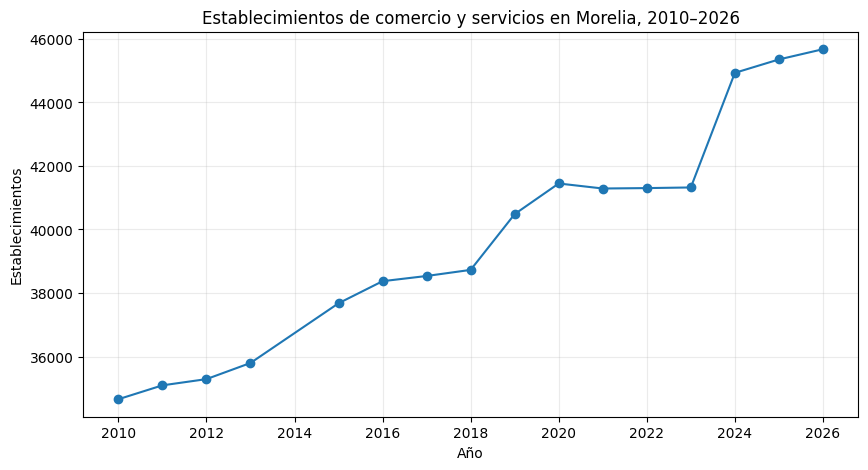

In [7]:

serie = control_reconstruido[["Año","Total_original","Amplitud_total"]].copy()
serie = serie.rename(columns={"Total_original":"Establecimientos"})
serie["Cambio_absoluto"] = serie["Establecimientos"].diff()
serie["Cambio_porcentual"] = serie["Establecimientos"].pct_change() * 100
serie["Años_desde_corte_anterior"] = serie["Año"].diff()

display(serie)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(serie["Año"], serie["Establecimientos"], marker="o")
ax.set_title("Establecimientos de comercio y servicios en Morelia, 2010–2026")
ax.set_xlabel("Año")
ax.set_ylabel("Establecimientos")
ax.grid(True, alpha=0.25)
plt.show()


**Precaución de lectura:** 2015 compara contra 2013 porque no existe corte seleccionado para 2014. Los saltos de 2019 y 2024 se auditan por separado y no se interpretan como crecimiento empresarial ordinario sin reservas.


## 7. Comercio al por menor frente a servicios

OK — macrogrupos reproducidos.


,Año,Macrogrupo,Establecimientos,Cambio_absoluto,Cambio_porcentual
0,2010,Comercio al por menor,16693,NaN,NaN
2,2011,Comercio al por menor,16824,131.0,0.784760
4,2012,Comercio al por menor,16860,36.0,0.213980
6,2013,Comercio al por menor,17045,185.0,1.097272
8,2015,Comercio al por menor,16955,-90.0,-0.528014
10,2016,Comercio al por menor,17313,358.0,2.111472
12,2017,Comercio al por menor,17427,114.0,0.658465
14,2018,Comercio al por menor,17452,25.0,0.143456
16,2019,Comercio al por menor,17642,190.0,1.088700
18,2020,Comercio al por menor,17984,342.0,1.938556


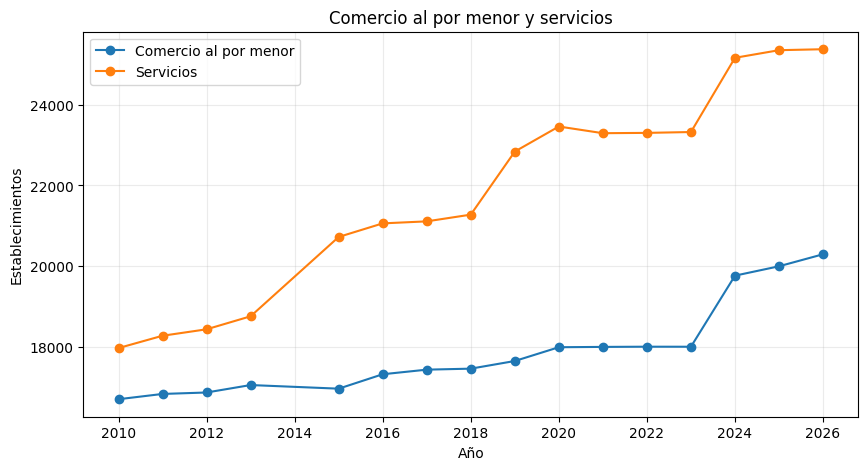

In [8]:

macro = inventario_reconstruido.copy()
macro["Macrogrupo"] = np.where(
    macro["Sector"].eq("46"),
    "Comercio al por menor",
    "Servicios"
)

macro = (
    macro.groupby(["Año","Macrogrupo"],as_index=False)["Establecimientos"].sum()
    .sort_values(["Macrogrupo","Año"])
)

macro["Cambio_absoluto"] = macro.groupby("Macrogrupo")["Establecimientos"].diff()
macro["Cambio_porcentual"] = macro.groupby("Macrogrupo")["Establecimientos"].pct_change() * 100

guardado_macro = pd.read_csv(RESULTADOS / "SERIE_HISTORICA_COMERCIO_VS_SERVICIOS_2010_2026.csv")
comparar = macro.merge(
    guardado_macro[["Año","Macrogrupo","Establecimientos"]],
    on=["Año","Macrogrupo"], suffixes=("_reconstruido","_guardado")
)
assert (comparar["Establecimientos_reconstruido"] == comparar["Establecimientos_guardado"]).all()

print("OK — macrogrupos reproducidos.")
display(macro)

fig, ax = plt.subplots(figsize=(10,5))
for nombre, g in macro.groupby("Macrogrupo"):
    ax.plot(g["Año"], g["Establecimientos"], marker="o", label=nombre)
ax.set_title("Comercio al por menor y servicios")
ax.set_xlabel("Año")
ax.set_ylabel("Establecimientos")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 8. Desagregación sectorial de servicios

In [9]:

nombres = {
    "48-49":"Transportes, correos y almacenamiento",
    "51":"Información en medios masivos",
    "52":"Servicios financieros y de seguros",
    "53":"Servicios inmobiliarios y de alquiler",
    "54":"Servicios profesionales, científicos y técnicos",
    "56":"Servicios de apoyo a los negocios y manejo de residuos",
    "61":"Servicios educativos",
    "62":"Servicios de salud y asistencia social",
    "71":"Servicios de esparcimiento, culturales y deportivos",
    "72":"Alojamiento temporal y preparación de alimentos y bebidas",
    "81":"Otros servicios excepto actividades gubernamentales",
}

serv = inventario_reconstruido[inventario_reconstruido["Sector"].isin(SECTORES_SERVICIOS)].copy()
serv["Sector_analisis"] = serv["Sector"].replace({"48":"48-49","49":"48-49"})

serie_sector = (
    serv.groupby(["Año","Sector_analisis"],as_index=False)["Establecimientos"].sum()
    .sort_values(["Sector_analisis","Año"])
)
serie_sector["Cambio_absoluto"] = serie_sector.groupby("Sector_analisis")["Establecimientos"].diff()
serie_sector["Cambio_porcentual"] = serie_sector.groupby("Sector_analisis")["Establecimientos"].pct_change() * 100
serie_sector["Nombre_sector"] = serie_sector["Sector_analisis"].map(nombres)

anios_clave = [2015,2019,2021,2024]
cambios_clave = serie_sector[serie_sector["Año"].isin(anios_clave)].copy()

total_serv = (
    macro[macro["Macrogrupo"].eq("Servicios")]
    .set_index("Año")["Cambio_absoluto"].to_dict()
)
cambios_clave["Cambio_total_servicios"] = cambios_clave["Año"].map(total_serv)
cambios_clave["Aporte_pct_al_cambio_servicios"] = (
    cambios_clave["Cambio_absoluto"] / cambios_clave["Cambio_total_servicios"] * 100
)
cambios_clave["Magnitud_cambio"] = cambios_clave["Cambio_absoluto"].abs()

guardado_sector = pd.read_csv(
    RESULTADOS / "SECTORES_EXPLICATIVOS_CAMBIOS_CLAVE_2015_2019_2021_2024.csv",
    dtype={"Sector_analisis":str}
)

cmp = cambios_clave.merge(
    guardado_sector[["Año","Sector_analisis","Cambio_absoluto"]],
    on=["Año","Sector_analisis"],
    suffixes=("_reconstruido","_guardado")
)
assert np.allclose(
    cmp["Cambio_absoluto_reconstruido"].astype(float),
    cmp["Cambio_absoluto_guardado"].astype(float),
    equal_nan=True
)

print("OK — cambios sectoriales clave reproducidos.")
display(
    cambios_clave.sort_values(["Año","Magnitud_cambio"],ascending=[True,False])[
        ["Año","Sector_analisis","Nombre_sector","Cambio_absoluto",
         "Cambio_total_servicios","Aporte_pct_al_cambio_servicios"]
    ].reset_index(drop=True)
)


OK — cambios sectoriales clave reproducidos.


,Año,Sector_analisis,Nombre_sector,Cambio_absoluto,Cambio_total_servicios,Aporte_pct_al_cambio_servicios
0,2015,72,Alojamiento temporal y preparación de alimento...,1162.0,1970.0,58.984772
1,2015,81,Otros servicios excepto actividades gubernamen...,825.0,1970.0,41.878173
2,2015,54,"Servicios profesionales, científicos y técnicos",-249.0,1970.0,-12.639594
3,2015,62,Servicios de salud y asistencia social,249.0,1970.0,12.639594
4,2015,48-49,"Transportes, correos y almacenamiento",-235.0,1970.0,-11.928934
5,2015,52,Servicios financieros y de seguros,179.0,1970.0,9.086294
6,2015,61,Servicios educativos,117.0,1970.0,5.939086
7,2015,56,Servicios de apoyo a los negocios y manejo de ...,-39.0,1970.0,-1.979695
8,2015,51,Información en medios masivos,-38.0,1970.0,-1.928934
9,2015,71,"Servicios de esparcimiento, culturales y depor...",-6.0,1970.0,-0.304569


## 9. Auditoría micro de SCIAN 812110

Las siguientes funciones reproducen la comparación por ID y dos huellas de establecimiento:

- **Huella exacta:** nombre + vialidad + números + CP + localidad + municipio + coordenadas.
- **Huella reducida:** nombre + vialidad + número exterior + localidad.

Las coincidencias por huella reducida se interpretan como **posibles correspondencias**, no como identidades demostradas.


In [10]:

def normalizar_huella(valor):
    if pd.isna(valor):
        return ""
    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"\s+", " ", texto)
    return texto

def construir_huella(df, columnas):
    h = df[columnas[0]].map(normalizar_huella)
    for col in columnas[1:]:
        h = h + "||" + df[col].map(normalizar_huella)
    return h

def auditar_812110(anio_inicial, anio_final):
    a = pd.read_csv(MORELIA / f"DENUE_{anio_inicial}_MORELIA.csv", dtype=str, low_memory=False)
    b = pd.read_csv(MORELIA / f"DENUE_{anio_final}_MORELIA.csv", dtype=str, low_memory=False)

    a = a[a["codigo_act"].astype(str).str.strip().eq("812110")].copy()
    b = b[b["codigo_act"].astype(str).str.strip().eq("812110")].copy()

    ids_a = set(a["id"].astype(str).str.strip())
    ids_b = set(b["id"].astype(str).str.strip())
    comunes = ids_a & ids_b
    solo_a = ids_a - ids_b
    solo_b = ids_b - ids_a

    ea = a[a["id"].astype(str).str.strip().isin(solo_a)].copy()
    eb = b[b["id"].astype(str).str.strip().isin(solo_b)].copy()

    exactas = ["nom_estab","nom_vial","numero_ext","numero_int","cod_postal",
               "localidad","municipio","latitud","longitud"]
    ea["H_EXACTA"] = construir_huella(ea, exactas)
    eb["H_EXACTA"] = construir_huella(eb, exactas)

    ca = ea["H_EXACTA"].value_counts()
    cb = eb["H_EXACTA"].value_counts()
    hx = {h for h in set(ca.index)&set(cb.index) if ca[h]==1 and cb[h]==1}

    px_a = ea[ea["H_EXACTA"].isin(hx)][["id","H_EXACTA"]].rename(columns={"id":"ID_inicial"})
    px_b = eb[eb["H_EXACTA"].isin(hx)][["id","H_EXACTA"]].rename(columns={"id":"ID_final"})
    pares_exactos = px_a.merge(px_b,on="H_EXACTA",how="inner",validate="one_to_one")

    usados_a = set(pares_exactos["ID_inicial"].astype(str))
    usados_b = set(pares_exactos["ID_final"].astype(str))
    ra = ea[~ea["id"].astype(str).isin(usados_a)].copy()
    rb = eb[~eb["id"].astype(str).isin(usados_b)].copy()

    reducidas = ["nom_estab","nom_vial","numero_ext","localidad"]
    ra["H_REDUCIDA"] = construir_huella(ra,reducidas)
    rb["H_REDUCIDA"] = construir_huella(rb,reducidas)

    cra = ra["H_REDUCIDA"].value_counts()
    crb = rb["H_REDUCIDA"].value_counts()
    hr = {h for h in set(cra.index)&set(crb.index) if cra[h]==1 and crb[h]==1}

    pr_a = ra[ra["H_REDUCIDA"].isin(hr)][["id","H_REDUCIDA"]].rename(columns={"id":"ID_inicial"})
    pr_b = rb[rb["H_REDUCIDA"].isin(hr)][["id","H_REDUCIDA"]].rename(columns={"id":"ID_final"})
    pares_reducidos = pr_a.merge(pr_b,on="H_REDUCIDA",how="inner",validate="one_to_one")

    usados_a |= set(pares_reducidos["ID_inicial"].astype(str))
    usados_b |= set(pares_reducidos["ID_final"].astype(str))

    final_a = ea[~ea["id"].astype(str).isin(usados_a)].copy()
    final_b = eb[~eb["id"].astype(str).isin(usados_b)].copy()

    fecha_corte = f"{anio_final}-11"
    n_fecha = final_b["fecha_alta"].astype(str).str.strip().eq(fecha_corte).sum()

    resumen = {
        "Transicion": f"{anio_inicial}-{anio_final}",
        "SCIAN": "812110",
        "Establecimientos_inicial": len(a),
        "Establecimientos_final": len(b),
        "Cambio_neto": len(b)-len(a),
        "IDs_presentes_en_ambos": len(comunes),
        "Exclusivos_inicial_raw": len(solo_a),
        "Exclusivos_final_raw": len(solo_b),
        "Posibles_cambios_ID": len(pares_exactos)+len(pares_reducidos),
        "Exclusivos_inicial_final": len(final_a),
        "Exclusivos_final_final": len(final_b),
        "Fecha_alta_corte": fecha_corte,
        "Exclusivos_con_fecha_corte": int(n_fecha),
        "Pct_exclusivos_con_fecha_corte": round(n_fecha/len(final_b)*100,2),
    }
    return resumen, pares_exactos, pares_reducidos, final_a, final_b


In [11]:

r19, exact19, redu19, solo18_final, solo19_final = auditar_812110(2018,2019)
r24, exact24, redu24, solo23_final, solo24_final = auditar_812110(2023,2024)

auditoria_reconstruida = pd.DataFrame([r19,r24])
auditoria_guardada = pd.read_csv(
    RESULTADOS / "RESUMEN_AUDITORIA_RUPTURAS_812110_2019_2024.csv",
    dtype={"SCIAN":str}
)

columnas_comparar = [
    "Transicion","Establecimientos_inicial","Establecimientos_final","Cambio_neto",
    "IDs_presentes_en_ambos","Exclusivos_inicial_raw","Exclusivos_final_raw",
    "Posibles_cambios_ID","Exclusivos_inicial_final","Exclusivos_final_final",
    "Exclusivos_con_fecha_corte","Pct_exclusivos_con_fecha_corte"
]

for col in columnas_comparar:
    if col == "Transicion":
        assert auditoria_reconstruida[col].tolist() == auditoria_guardada[col].tolist()
    else:
        assert np.allclose(
            pd.to_numeric(auditoria_reconstruida[col]),
            pd.to_numeric(auditoria_guardada[col])
        )

print("OK — auditorías 2019 y 2024 reproducidas desde registros individuales.")
display(auditoria_reconstruida)


OK — auditorías 2019 y 2024 reproducidas desde registros individuales.


,Transicion,SCIAN,Establecimientos_inicial,Establecimientos_final,Cambio_neto,IDs_presentes_en_ambos,Exclusivos_inicial_raw,Exclusivos_final_raw,Posibles_cambios_ID,Exclusivos_inicial_final,Exclusivos_final_final,Fecha_alta_corte,Exclusivos_con_fecha_corte,Pct_exclusivos_con_fecha_corte
0,2018-2019,812110,1767,2328,561,935,832,1393,3,829,1390,2019-11,1363,98.06
1,2023-2024,812110,2334,3128,794,1390,944,1738,1,943,1737,2024-11,1688,97.18


### 9.1 Posibles cambios de ID identificados

In [12]:

print("2018–2019 — huella exacta")
display(exact19)
print("2018–2019 — huella reducida")
display(redu19)

print("2023–2024 — huella exacta")
display(exact24)
print("2023–2024 — huella reducida")
display(redu24)


2018–2019 — huella exacta


,ID_inicial,H_EXACTA,ID_final
0,2583057,ESTETICA SIMONE||ANASTASIO BUSTAMANTE||80||||5...,8749175


2018–2019 — huella reducida


,ID_inicial,H_REDUCIDA,ID_final
0,2612777,ESTETICA ARA||VICENTE GUERRERO||391||MORELIA,8072000
1,2613825,ESTETICA CIRI||TORREON NUEVO||521||MORELIA,8452308


2023–2024 — huella exacta


,ID_inicial,H_EXACTA,ID_final


2023–2024 — huella reducida


,ID_inicial,H_REDUCIDA,ID_final
0,2574745,PELUQUERIA||LAZARO CARDENAS||526||MORELIA,6976777


### 9.2 Distribución de `fecha_alta` en los exclusivos finales

In [13]:

def distribucion_fecha(df):
    out = (
        df["fecha_alta"].fillna("SIN DATO").astype(str).str.strip()
        .value_counts().rename_axis("fecha_alta").reset_index(name="Establecimientos")
    )
    out["Porcentaje"] = out["Establecimientos"] / len(df) * 100
    return out

print("Exclusivos finales 2019")
display(distribucion_fecha(solo19_final))

print("Exclusivos finales 2024")
display(distribucion_fecha(solo24_final))


Exclusivos finales 2019


,fecha_alta,Establecimientos,Porcentaje
0,2019-11,1363,98.057554
1,2014-12,16,1.151079
2,2010-07,11,0.791367


Exclusivos finales 2024


,fecha_alta,Establecimientos,Porcentaje
0,2024-11,1688,97.179044
1,2019-11,29,1.669545
2,2010-07,12,0.690846
3,2014-12,5,0.287853
4,2020-11,2,0.115141
5,2021-05,1,0.057571


## 10. Control puntual del código 531116

El inventario histórico contiene **un establecimiento 531116 en 2022**. La narrativa de la familia FL03 fue corregida para reflejar este dato; este control conserva la verificación explícita dentro del flujo reproducible.


In [14]:

control_531116 = inventario_reconstruido[
    inventario_reconstruido["SCIAN_original"].eq("531116")
].copy()

display(control_531116)

assert len(control_531116) == 1
assert int(control_531116.iloc[0]["Año"]) == 2022
assert int(control_531116.iloc[0]["Establecimientos"]) == 1

print("OK — se conserva el registro observado de 531116 en 2022.")


,Año,Version_SCIAN,SCIAN_original,Sector,Establecimientos
4543,2022,SCIAN 2018,531116,53,1


OK — se conserva el registro observado de 531116 en 2022.


## 11. Resumen de controles

In [15]:

controles = pd.DataFrame([
    ["Inventario desde 16 conteos", len(inventario_reconstruido)==6435],
    ["350 unidades homologadas", diccionario["Unidad_homologada"].nunique()==350],
    ["Cobertura de 4 versiones", (cobertura==4).all()],
    ["Sin códigos observados sin mapear", inventario_homologado["Unidad_homologada"].isna().sum()==0],
    ["Panel 350 × 16", len(panel_reconstruido)==5600],
    ["Panel agregado coincide con guardado",
     (comparacion["Establecimientos_agregados"].astype(int)==comparacion["Establecimientos"].astype(int)).all()],
    ["Conservación total máximo", (control_reconstruido["Diferencia_max_original"]==0).all()],
    ["Amplitud máxima de incertidumbre = 1", panel_reconstruido["Incertidumbre"].max()==1],
    ["Macrogrupos reproducidos",
     (comparar["Establecimientos_reconstruido"]==comparar["Establecimientos_guardado"]).all()],
    ["Auditoría 2019 reproducida", r19["Cambio_neto"]==561 and r19["Pct_exclusivos_con_fecha_corte"]==98.06],
    ["Auditoría 2024 reproducida", r24["Cambio_neto"]==794 and r24["Pct_exclusivos_con_fecha_corte"]==97.18],
], columns=["Control","OK"])

display(controles)

if not controles["OK"].all():
    raise AssertionError("Existe al menos un control no satisfecho.")

print("TODOS LOS CONTROLES: OK")


,Control,OK
0,Inventario desde 16 conteos,True
1,350 unidades homologadas,True
2,Cobertura de 4 versiones,True
3,Sin códigos observados sin mapear,True
4,Panel 350 × 16,True
5,Panel agregado coincide con guardado,True
6,Conservación total máximo,True
7,Amplitud máxima de incertidumbre = 1,True
8,Macrogrupos reproducidos,True
9,Auditoría 2019 reproducida,True


TODOS LOS CONTROLES: OK


## 12. Interpretación metodológica

Los resultados reproducidos permiten sostener que:

- la serie histórica puede compararse después de homologar las versiones SCIAN;
- el panel conserva los totales observados de cada corte;
- la incertidumbre intersectorial de FL09 queda acotada a un establecimiento;
- los movimientos de 2019 y 2024 contienen una recomposición amplia del directorio;
- `fecha_alta` no debe usarse como sinónimo automático de nacimiento empresarial;
- las apariciones y ausencias deben describirse de forma prudente como incorporación, presencia, ausencia o desaparición del registro, salvo que una fuente metodológica adicional permita una interpretación demográfica más fuerte.

El cuaderno `02_BITACORA_ORIGINAL_DENUE.ipynb` conserva la trazabilidad completa del trabajo realizado durante la construcción del análisis.
